In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cooltools
from scipy.optimize import fsolve
from numpy import nanmean
import pandas as pd
import bioframe
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import cooler
from coolpuppy import coolpup

%matplotlib inline



ModuleNotFoundError: No module named 'cooltools'

In [126]:
chipdata="/Users/dariodasaro/Desktop/PhD_data/ENS/mcpoly_data/GSE151416_RAW"+"/GSM4577764_Mcd1p_WT.bigwig"

chroms = ['chrI',
 'chrII',
 'chrIII',
 'chrIV',
 'chrV',
 'chrVI',
 'chrVII',
 'chrVIII',
 'chrIX',
 'chrX',
 'chrXI',
 'chrXII',
 'chrXIII',
 'chrXIV',
 'chrXV',
 'chrXVI']


(200000.0, 300000.0)

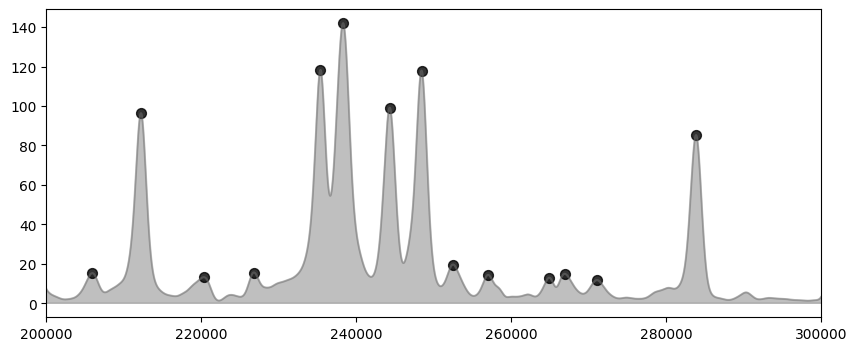

In [133]:
## example loading a bigwig file and plotting the data for a specific chromosome
plt.figure(figsize=(10, 4))
#load dataframe from bigwig file for chromosome II
df1 = bioframe.read_bigwig(chipdata, 'chrII')

#note that bins have different sizes, in this case I interploate but you may also rebin to the scale is meaningful for your simulations
pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
enrichment = df1['value'].values

# Regular grid (1 bp spacing here)
pos_uniform = np.arange(pos.min(), pos.max()+1)

# Interpolate
f = interp1d(pos, enrichment,
             kind='linear',
             bounds_error=False,
             fill_value='extrapolate')

enrichment_uniform = f(pos_uniform)

# Smooth 
enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=500)

plt.plot(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)
plt.fill_between(pos_uniform,enrichment_smooth,color="gray",alpha=0.5)



#find peaks in the data using scipy find_peaks function, with a minimum height of min_h and a minimum distance of min_d between peaks.
min_h=10
min_d=500
prominence=0.5
peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)

plt.scatter(pos_uniform[peaks], enrichment_smooth[peaks], color="black", s=50, alpha=0.8)
plt.xlim(200000, 300000)


In [134]:
#create a dataframe with the peaks heights and positions

CARs_df = []
for chrom in chroms[:]:
    df1 = bioframe.read_bigwig(chipdata, chrom)
    pos= np.array(df1["start"])+ np.rint(df1["end"]/2-df1["start"]/2)
    enrichment = df1['value'].values
    pos_uniform = np.arange(pos.min(), pos.max()+1)
    f = interp1d(pos, enrichment,
                 kind='linear',
                 bounds_error=False,
                 fill_value='extrapolate')
    enrichment_uniform = f(pos_uniform)
    enrichment_smooth = gaussian_filter1d(enrichment_uniform, sigma=1000)
    peaks, _ = find_peaks(enrichment_smooth,height=min_h,distance=int(min_d),prominence=prominence)
    chrom_df = pd.DataFrame({'chrom': chrom, 'start': pos_uniform[peaks], 'end': pos_uniform[peaks], 'CAR strength': enrichment_smooth[peaks]})
    CARs_df.append(chrom_df)
CARs_df = pd.concat(CARs_df, ignore_index=True)


In [78]:
## create df for cooltools off-diagonal plots using only NN CARS

CARs_df_NN=[]

for chrom in chroms[:]:
    CARs_df_NN_chrom =pd.DataFrame(columns=['chrom1', 'start1', 'end1', 'CAR strength1', 'chrom2', 'start2', 'end2', 'CAR strength2'])


    chrom_mask = CARs_df["chrom"]==chrom
   
    #you may want to add a filter for the CAR strength, for example only consider CARs with strength above a certain threshold
    #strength_mask = CARs_df[chrom_mask]["CAR strength"] > 2

    CARs_df_NN_chrom["chrom1"]=list(CARs_df[chrom_mask][:-1]["chrom"])
    CARs_df_NN_chrom["chrom2"]=list(CARs_df[chrom_mask][1:]["chrom"])

    CARs_df_NN_chrom["start1"]=list(CARs_df[chrom_mask][:-1]["start"])
    CARs_df_NN_chrom["start2"]=list(CARs_df[chrom_mask][1:]["start"]) 

    CARs_df_NN_chrom["end1"]=list(CARs_df[chrom_mask][:-1]["end"])
    CARs_df_NN_chrom["end2"]=list(CARs_df[chrom_mask][1:]["end"])

    CARs_df_NN_chrom["CAR strength1"]=list(CARs_df[chrom_mask][:-1]["CAR strength"])
    CARs_df_NN_chrom["CAR strength2"]=list(CARs_df[chrom_mask][1:]["CAR strength"])

    CARs_df_NN.append(CARs_df_NN_chrom)

CARs_df_NN = pd.concat(CARs_df_NN, ignore_index=True)




In [ ]:
#Load cooler file and create expected dataframe for the off-diagonal plots

resolution=1000
clr = cooler.Cooler("/Users/dariodasaro/Desktop/PhD_data/ENS/mcpoly_data/GSE151553_A364_merged1kb.mcool::/resolutions/" + str(resolution))
view_df=pd.DataFrame({"chrom":clr.chromnames,"start":0,"end":clr.chromsizes.values,"name":clr.chromnames})


#compute expected cis using cooltools (a df containing the P(s))
cvd = cooltools.expected_cis(
clr=clr,
    view_df=view_df,
    clr_weight_name="weight",
    smooth=True,
    aggregate_smoothed=False,
    nproc=8 #if you do not have multiple cores available, set to 1
    )



flank= 5_000 #window size NB this is also the minimal distance between CARs that will be considered. If you consider too many low strength CARs that may be a problem

# create the stack of snips:
pup = coolpup.pileup(
    clr,
    CARs_df_NN,
    features_format='bedpe',
    flank=flank,
    view_df=view_df,
    expected_df=cvd,
    clr_weight_name="weight",
    nproc=8
)

INFO:root:creating a Pool of 8 workers
/Users/dariodasaro/venvs/mcpoly_analysis/lib/python3.9/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/Users/dariodasaro/venvs/mcpoly_analysis/lib/python3.9/site-packages/cooltools/api/snipping.py:762: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/Users/dariodasaro/venvs/mcpoly_analysis/lib/python3.9/site-packages/cooltools/api/snipping.py:765: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys w

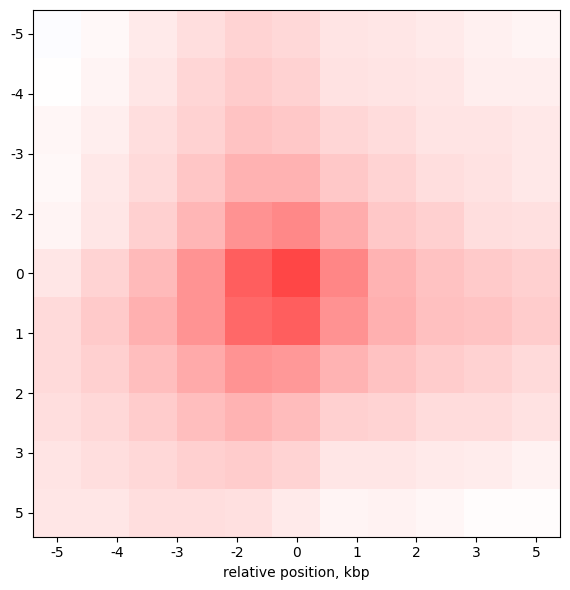

In [114]:
fig, ax = plt.subplots(figsize=(6, 6))
mtx=pup.loc[0, 'data']
im=ax.imshow(
    np.log2((mtx)),
    cmap='bwr',
    vmin=-2,
    vmax=2,
interpolation='none')

ticks_pixels = np.linspace(0, flank*2//resolution,9)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)
ax.set(
    xticks=ticks_pixels,
    xticklabels=ticks_kbp,
    yticks=ticks_pixels,
    yticklabels=ticks_kbp,
    xlabel='relative position, kbp'
    )
        
fig.tight_layout()

